In [1]:
# ============================================================
# Upload Dataset Files
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded Files:")
print(list(uploaded.keys()))

Saving dev_en_1000.csv to dev_en_1000.csv
Saving dev_sa_1000.csv to dev_sa_1000.csv
Saving test_en_1000.csv to test_en_1000.csv
Saving test_sa_1000.csv to test_sa_1000.csv
Saving train_en_10000.csv to train_en_10000.csv
Saving train_sa_10000.csv to train_sa_10000.csv

Uploaded Files:
['dev_en_1000.csv', 'dev_sa_1000.csv', 'test_en_1000.csv', 'test_sa_1000.csv', 'train_en_10000.csv', 'train_sa_10000.csv']


In [3]:
import os

os.rename("train_sa_10000.csv", "train_sa.csv")
os.rename("train_en_10000.csv", "train_en.csv")

os.rename("dev_sa_1000.csv", "dev_sa.csv")
os.rename("dev_en_1000.csv", "dev_en.csv")

os.rename("test_sa_1000.csv", "test_sa.csv")
os.rename("test_en_1000.csv", "test_en.csv")

print("Files renamed successfully!")

Files renamed successfully!


In [2]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip -q install bert-score nltk torchinfo

import nltk

nltk.download("punkt", quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


True

In [5]:
# ============================================================
# Import Libraries
# ============================================================

import os
import re
import time
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence
)

from nltk.translate.bleu_score import corpus_bleu

from bert_score import score as bertscore

import copy
from pathlib import Path

warnings.filterwarnings("ignore")

In [81]:
class CFG:

    # Random Seed
    SEED = 42

    # Dataset
    TRAIN_SA = "train_sa.csv"
    TRAIN_EN = "train_en.csv"

    DEV_SA = "dev_sa.csv"
    DEV_EN = "dev_en.csv"

    TEST_SA = "test_sa.csv"

    # Vocabulary
    MIN_FREQ = 1

    # Model
    EMBEDDING_DIM = 256
    HIDDEN_DIM = 256
    NUM_LAYERS = 1

    ENC_DROPOUT = 0.3
    DEC_DROPOUT = 0.3

    # Training
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 30
    TEACHER_FORCING = 0.7
    CLIP = 1.0
    PATIENCE = 4
    WEIGHT_DECAY=1e-5
    EARLY_STOPPING_DELTA = 0.0

    # Beam Search
    BEAM_SIZE = 3

    # Output
    OUTPUT_DIR = "outputs"

    # Device
    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

In [9]:
# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
      torch.cuda.manual_seed(CFG.SEED)
      torch.cuda.manual_seed_all(CFG.SEED)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(CFG.SEED)

print("="*50)
print("Device :", CFG.DEVICE)
print("Random Seed :", CFG.SEED)
print("="*50)

Device : cuda
Random Seed : 42


In [10]:
# ============================================================
# Create Output Directory
# ============================================================

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

print("Output Directory:", CFG.OUTPUT_DIR)

Output Directory: outputs


In [11]:
# ============================================================
# Load Dataset
# ============================================================

def load_parallel_data(sa_file, en_file):
    """
    Loads Sanskrit and English CSV files and merges them
    using Source_id.

    Parameters
    ----------
    sa_file : str
        Sanskrit CSV file

    en_file : str
        English CSV file

    Returns
    -------
    pandas.DataFrame
    """

    sa_df = pd.read_csv(sa_file)

    en_df = pd.read_csv(en_file)

    df = sa_df.merge(
        en_df,
        on="Source_id"
    )

    return df


def load_test_data(test_file):

    return pd.read_csv(test_file)

In [12]:
# ============================================================
# Read Dataset
# ============================================================

required_files = [

    CFG.TRAIN_SA,
    CFG.TRAIN_EN,

    CFG.DEV_SA,
    CFG.DEV_EN,

    CFG.TEST_SA

]

if all(os.path.exists(file) for file in required_files):



    train_df = load_parallel_data(
        CFG.TRAIN_SA,
        CFG.TRAIN_EN
    )

    dev_df = load_parallel_data(
        CFG.DEV_SA,
        CFG.DEV_EN
    )

    test_df = load_test_data(
        CFG.TEST_SA
    )

    print("Train Shape :", train_df.shape)
    print("Dev Shape   :", dev_df.shape)
    print("Test Shape  :", test_df.shape)

    display(train_df.head())

else:

    print("Training files not found.")
    print("Waiting for evaluation dataset...")

Train Shape : (10000, 3)
Dev Shape   : (1000, 3)
Test Shape  : (1000, 2)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [13]:
print("\nTrain Columns")

print(train_df.columns)


Train Columns
Index(['Source_id', 'Sentence_sa', 'Sentence_en'], dtype='object')


In [18]:
# ============================================================
# Dataset Statistics
# ============================================================

def dataset_statistics(df, name):

    print("="*60)
    print(name)
    print("="*60)

    print("Total Samples :", len(df))

    print()

    print("Missing Values")

    print(df.isnull().sum())

    print()

    print(df.head())

    df["sa_length"] = df["Sentence_sa"].str.split().apply(len)

    df["en_length"] = df["Sentence_en"].str.split().apply(len)

    print(df["sa_length"].describe())

    print(df["en_length"].describe())

    print(

        "Duplicate Source IDs :",

        df["Source_id"].duplicated().sum()

    )

    Counter(

        " ".join(df["Sentence_en"]).split()

    ).most_common(10)


if "train_df" in globals():

    dataset_statistics(train_df, "Training Dataset")

    dataset_statistics(dev_df, "Validation Dataset")

Training Dataset
Total Samples : 10000

Missing Values
Source_id      0
Sentence_sa    0
Sentence_en    0
sa_length      0
en_length      0
dtype: int64

   Source_id                                        Sentence_sa  \
0          1                         "Ctrl, S नुत्वा रक्षन्तु।"   
1          2                     गुरुः छात्रान् एकवारं पाठयति ।   
2          3  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...   
3          4       वयं  Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।   
4          5  "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...   

                                         Sentence_en  sa_length  en_length  
0                              Save it with Ctrl, S.          4          5  
1         Teacher will teach the students only once.          5          7  
2  To recreate this animation, I have to take two...         12         18  
3    I will choose Colors options by clicking on it.          7          9  
4  "See the example here - one mountain, four vil...      

In [19]:
assert len(train_df) > 0

assert len(dev_df) > 0

assert len(test_df) > 0

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [20]:
# ============================================================
# Text Preprocessing
# ============================================================

def clean_sanskrit(sentence):
    """
    Cleans Sanskrit text while preserving the Devanagari script.
    """

    if pd.isna(sentence):
        return ""

    sentence = str(sentence)

    # Remove extra spaces
    sentence = re.sub(r"\s+", " ", sentence)

    # Separate Sanskrit punctuation
    sentence = re.sub(r"([।॥])", r" \1 ", sentence)

    # Separate common punctuation
    sentence = re.sub(r"([,;:!?()\"'])", r" \1 ", sentence)

    # Remove extra spaces again
    sentence = re.sub(r"\s+", " ", sentence)

    return sentence.strip()


def clean_english(sentence):
    """
    Cleans English text.
    """

    if pd.isna(sentence):
        return ""

    sentence = str(sentence).lower()

    # Separate punctuation
    sentence = re.sub(r"([.,!?;:()\"'])", r" \1 ", sentence)

    # Remove extra spaces
    sentence = re.sub(r"\s+", " ", sentence)

    return sentence.strip()


def tokenize(sentence):
    """
    Simple whitespace tokenizer.
    """

    return sentence.split()

In [21]:
# ============================================================
# Apply Text Preprocessing
# ============================================================

train_df["Sentence_sa"] = train_df["Sentence_sa"].apply(clean_sanskrit)
train_df["Sentence_en"] = train_df["Sentence_en"].apply(clean_english)

dev_df["Sentence_sa"] = dev_df["Sentence_sa"].apply(clean_sanskrit)
dev_df["Sentence_en"] = dev_df["Sentence_en"].apply(clean_english)

test_df["Sentence_sa"] = test_df["Sentence_sa"].apply(clean_sanskrit)

print("Text preprocessing completed.\n")

display(train_df.head())

Text preprocessing completed.



,Source_id,Sentence_sa,Sentence_en,sa_length,en_length
0,1,""" Ctrl , S नुत्वा रक्षन्तु । ""","save it with ctrl , s .",4,5
1,2,गुरुः छात्रान् एकवारं पाठयति ।,teacher will teach the students only once .,5,7
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"to recreate this animation , i have to take tw...",12,18
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,i will choose colors options by clicking on it .,7,9
4,5,""" अत्र कानिचन उदाहरणानि पश्याम : - एक : पर्वत ...",""" see the example here - one mountain , four v...",15,17


In [22]:
# ============================================================
# Apply Text Preprocessing
# ============================================================

if "train_df" in globals():

    # Training Set
    train_df["Sentence_sa"] = train_df["Sentence_sa"].apply(clean_sanskrit)
    train_df["Sentence_en"] = train_df["Sentence_en"].apply(clean_english)

    # Validation Set
    dev_df["Sentence_sa"] = dev_df["Sentence_sa"].apply(clean_sanskrit)
    dev_df["Sentence_en"] = dev_df["Sentence_en"].apply(clean_english)

    # Test Set
    test_df["Sentence_sa"] = test_df["Sentence_sa"].apply(clean_sanskrit)

    print("=" * 60)
    print("Text Preprocessing Completed Successfully")
    print("=" * 60)

    print("\nSample Training Example\n")

    print("Sanskrit :")
    print(train_df.iloc[0]["Sentence_sa"])

    print("\nEnglish :")
    print(train_df.iloc[0]["Sentence_en"])

else:

    print("Dataset not loaded.")

Text Preprocessing Completed Successfully

Sample Training Example

Sanskrit :
" Ctrl , S नुत्वा रक्षन्तु । "

English :
save it with ctrl , s .


In [25]:
# ============================================================
# Verify Tokenization
# ============================================================

sample_sa = train_df.iloc[0]["Sentence_sa"]
sample_en = train_df.iloc[0]["Sentence_en"]

print("Sanskrit Tokens")
print(tokenize(sample_sa))

print()

print("English Tokens")
print(tokenize(sample_en))

print("\nTotal Training Samples :", len(train_df))
print("Total Validation Samples :", len(dev_df))
print("Total Test Samples :", len(test_df))

Sanskrit Tokens
['"', 'Ctrl', ',', 'S', 'नुत्वा', 'रक्षन्तु', '।', '"']

English Tokens
['save', 'it', 'with', 'ctrl', ',', 's', '.']

Total Training Samples : 10000
Total Validation Samples : 1000
Total Test Samples : 1000


In [30]:
# ============================================================
# Vocabulary Class
# ============================================================

class Vocabulary:
    """
    Vocabulary class for mapping words to integer IDs and
    integer IDs back to words.
    """

    def __init__(self, min_freq=1):

        self.min_freq = min_freq

        # Word Frequencies
        self.freqs = Counter()

        # Special Tokens
        self.special_tokens = [
            "<PAD>",
            "<SOS>",
            "<EOS>",
            "<UNK>"
        ]

        # Word → Index
        self.word2idx = {}

        # Index → Word
        self.idx2word = {}

        # Add Special Tokens
        for idx, token in enumerate(self.special_tokens):

            self.word2idx[token] = idx

            self.idx2word[idx] = token

        # Frequently Used Token IDs
        self.pad_idx = self.word2idx["<PAD>"]
        self.sos_idx = self.word2idx["<SOS>"]
        self.eos_idx = self.word2idx["<EOS>"]
        self.unk_idx = self.word2idx["<UNK>"]

    def build(self, sentences):
        """
        Build vocabulary from a list of sentences.
        """

        # Count Token Frequencies
        for sentence in sentences:

            tokens = tokenize(sentence)

            self.freqs.update(tokens)

        current_index = len(self.word2idx)

        # Add Tokens Meeting Minimum Frequency
        for word, frequency in self.freqs.items():

            if frequency >= self.min_freq:

                if word not in self.word2idx:

                    self.word2idx[word] = current_index

                    self.idx2word[current_index] = word

                    current_index += 1

    def numericalize(self, sentence):
        """
        Convert a sentence into token IDs.
        """

        tokens = tokenize(sentence)

        ids = [self.sos_idx]

        for token in tokens:

            ids.append(

                self.word2idx.get(
                    token,
                    self.unk_idx
                )

            )

        ids.append(self.eos_idx)

        return ids

    def decode(self, token_ids):
        """
        Convert token IDs back to a sentence.
        """

        words = []

        for idx in token_ids:

            idx = int(idx)

            if idx == self.eos_idx:

                break

            if idx in (self.pad_idx, self.sos_idx):

                continue

            words.append(

                self.idx2word.get(
                    idx,
                    "<UNK>"
                )

            )

        return " ".join(words)

    def __len__(self):

        return len(self.word2idx)

    def lookup_token(self, index):
      """
      Returns token corresponding to an index.
      """

      return self.idx2word.get(
            index,
            "<UNK>"
      )

    def lookup_index(self, token):
      """
      Returns index corresponding to a token.
      """

      return self.word2idx.get(
          token,
          self.unk_idx
      )

In [31]:
# ============================================================
# Build Vocabulary
# ============================================================

source_vocab = Vocabulary(CFG.MIN_FREQ)
target_vocab = Vocabulary(CFG.MIN_FREQ)

# Build Source Vocabulary
source_vocab.build(
    train_df["Sentence_sa"].tolist()
)

# Build Target Vocabulary
target_vocab.build(
    train_df["Sentence_en"].tolist()
)

print("=" * 60)
print("Vocabulary Construction Completed")
print("=" * 60)

print(f"Source Vocabulary Size : {len(source_vocab):,}")
print(f"Target Vocabulary Size : {len(target_vocab):,}")

print("\nSpecial Token IDs")
print("-" * 30)
print(f"<PAD> : {source_vocab.pad_idx}")
print(f"<SOS> : {source_vocab.sos_idx}")
print(f"<EOS> : {source_vocab.eos_idx}")
print(f"<UNK> : {source_vocab.unk_idx}")

Vocabulary Construction Completed
Source Vocabulary Size : 29,925
Target Vocabulary Size : 10,880

Special Token IDs
------------------------------
<PAD> : 0
<SOS> : 1
<EOS> : 2
<UNK> : 3


In [32]:
# ============================================================
# Vocabulary Analysis
# ============================================================

print("=" * 60)
print("Top 20 Sanskrit Tokens")
print("=" * 60)

print(source_vocab.freqs.most_common(20))

print("\n")

print("=" * 60)
print("Top 20 English Tokens")
print("=" * 60)

print(target_vocab.freqs.most_common(20))

print("\n")

sample_sa = train_df.iloc[0]["Sentence_sa"]
sample_en = train_df.iloc[0]["Sentence_en"]

print("=" * 60)
print("Vocabulary Verification")
print("=" * 60)

print("\nSample Sanskrit Sentence")
print(sample_sa)

print("\nNumericalized")
print(source_vocab.numericalize(sample_sa))

print("\nDecoded")

print(
    source_vocab.decode(
        source_vocab.numericalize(sample_sa)
    )
)

print("\n")

print("Sample English Sentence")
print(sample_en)

print("\nNumericalized")
print(target_vocab.numericalize(sample_en))

print("\nDecoded")

print(
    target_vocab.decode(
        target_vocab.numericalize(sample_en)
    )
)

Top 20 Sanskrit Tokens
[('।', 9463), (',', 3891), (':', 3421), ('"', 2127), ('इति', 1195), ('च', 1049), ('तथा', 659), ("'", 638), ('वयं', 633), ('न', 616), ('अपि', 582), (')', 580), ('(', 572), ('मध्ये', 551), ('इतीदं', 521), ('भवति', 468), ('इत्यस्य', 416), ('स', 415), ('अस्ति', 408), ('?', 375)]


Top 20 English Tokens
[('.', 10010), ('the', 9091), (',', 7134), ('"', 4688), ('and', 4529), ('of', 3146), ('to', 3055), ('in', 2325), ('is', 2235), ('a', 1813), ('that', 1369), ('this', 1338), ('we', 1255), ('on', 1241), ('i', 1171), (':', 1149), ('for', 1149), ('you', 1121), ('it', 940), ('are', 917)]


Vocabulary Verification

Sample Sanskrit Sentence
" Ctrl , S नुत्वा रक्षन्तु । "

Numericalized
[1, 4, 5, 6, 7, 8, 9, 10, 4, 2]

Decoded
" Ctrl , S नुत्वा रक्षन्तु । "


Sample English Sentence
save it with ctrl , s .

Numericalized
[1, 4, 5, 6, 7, 8, 9, 10, 2]

Decoded
save it with ctrl , s .


In [36]:
# ============================================================
# Translation Dataset
# ============================================================

class TranslationDataset(Dataset):
    """
    Dataset class for Sanskrit-to-English translation.
    """

    def __init__(
        self,
        dataframe,
        source_vocab,
        target_vocab
    ):

        self.dataframe = dataframe
        self.source_vocab = source_vocab
        self.target_vocab = target_vocab

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        source_sentence = row["Sentence_sa"]
        target_sentence = row["Sentence_en"]

        source_ids = self.source_vocab.numericalize(
            source_sentence
        )

        target_ids = self.target_vocab.numericalize(
            target_sentence
        )

        return (

            torch.tensor(
                source_ids,
                dtype=torch.long
            ),

            torch.tensor(
                target_ids,
                dtype=torch.long
            )

        )

In [37]:
# ============================================================
# Collate Function
# ============================================================

PAD_IDX = source_vocab.pad_idx


def collate_fn(batch):
    """
    Pads variable-length source and target sequences
    within a mini-batch.
    """

    source_batch, target_batch = zip(*batch)

    source_lengths = torch.tensor(
        [len(sentence) for sentence in source_batch],
        dtype=torch.long
    )

    source_batch = pad_sequence(
        source_batch,
        batch_first=True,
        padding_value=PAD_IDX
    )

    target_batch = pad_sequence(
        target_batch,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return (
        source_batch,
        target_batch,
        source_lengths
    )

In [38]:
# ============================================================
# Verify Collate Function
# ============================================================

sample_dataset = TranslationDataset(
    train_df,
    source_vocab,
    target_vocab
)

sample_batch = [
    sample_dataset[0],
    sample_dataset[1]
]

source_batch, target_batch, source_lengths = collate_fn(sample_batch)

print("Source Batch Shape :", source_batch.shape)
print("Target Batch Shape :", target_batch.shape)
print("Source Lengths :", source_lengths)

Source Batch Shape : torch.Size([2, 10])
Target Batch Shape : torch.Size([2, 10])
Source Lengths : tensor([10,  7])


In [40]:
# ============================================================
# Create Translation Datasets
# ============================================================

train_dataset = TranslationDataset(
    dataframe=train_df,
    source_vocab=source_vocab,
    target_vocab=target_vocab
)

dev_dataset = TranslationDataset(
    dataframe=dev_df,
    source_vocab=source_vocab,
    target_vocab=target_vocab
)

print("=" * 60)
print("Dataset Creation Completed")
print("=" * 60)

print(f"Training Samples   : {len(train_dataset):,}")
print(f"Validation Samples : {len(dev_dataset):,}")

Dataset Creation Completed
Training Samples   : 10,000
Validation Samples : 1,000


In [41]:
# ============================================================
# Create DataLoaders
# ============================================================

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dataset=dev_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("=" * 60)
print("DataLoader Creation Completed")
print("=" * 60)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(dev_loader)}")

DataLoader Creation Completed
Training Batches   : 313
Validation Batches : 32


In [42]:
# ============================================================
# Verify Data Pipeline
# ============================================================

source_batch, target_batch, source_lengths = next(iter(train_loader))

print("=" * 60)
print("Data Pipeline Verification")
print("=" * 60)

print(f"Source Batch Shape : {source_batch.shape}")
print(f"Target Batch Shape : {target_batch.shape}")
print(f"Source Length Shape: {source_lengths.shape}")

print("\nFirst Five Source Lengths")
print(source_lengths[:5])

print("\nFirst Source Sequence")
print(source_batch[0])

print("\nFirst Target Sequence")
print(target_batch[0])

Data Pipeline Verification
Source Batch Shape : torch.Size([32, 30])
Target Batch Shape : torch.Size([32, 38])
Source Length Shape: torch.Size([32])

First Five Source Lengths
tensor([12, 17, 16, 10,  6])

First Source Sequence
tensor([   1,   31, 2676, 5503, 5504, 1612, 2322,  875,  248, 5505,   10,    2,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])

First Target Sequence
tensor([   1,   22, 1230,  216, 1231, 1232,   92,   31,  100,   94,   18, 3230,
         138, 1808,   43,   10,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])


In [43]:
# ============================================================
# Verify Numericalization and Decoding
# ============================================================

sample_source, sample_target = train_dataset[0]

print("=" * 60)
print("Vocabulary Verification")
print("=" * 60)

print("\nOriginal Sanskrit")
print(train_df.iloc[0]["Sentence_sa"])

print("\nRecovered Sanskrit")
print(source_vocab.decode(sample_source.tolist()))

print("\nOriginal English")
print(train_df.iloc[0]["Sentence_en"])

print("\nRecovered English")
print(target_vocab.decode(sample_target.tolist()))

Vocabulary Verification

Original Sanskrit
" Ctrl , S नुत्वा रक्षन्तु । "

Recovered Sanskrit
" Ctrl , S नुत्वा रक्षन्तु । "

Original English
save it with ctrl , s .

Recovered English
save it with ctrl , s .


In [56]:
# ============================================================
# Encoder
# ============================================================

class Encoder(nn.Module):
    """
    Encoder Network

    Input:
        source sentence
        Shape : (batch_size, source_length)

    Output:
        encoder_outputs
            Shape :
            (batch_size,
             source_length,
             hidden_dim)

        hidden
            Shape :
            (1,
             batch_size,
             hidden_dim)

        cell
            Shape :
            (1,
             batch_size,
             hidden_dim)
    """

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim,
        dropout
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=embedding_dim,
            padding_idx=PAD_IDX
        )

        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(

            input_size=embedding_dim,

            hidden_size=hidden_dim,

            num_layers=CFG.NUM_LAYERS,

            batch_first=True,

        )

    def forward(
        self,
        source,
        source_lengths
    ):

        embedded = self.dropout(
            self.embedding(source)
        )

        packed = pack_padded_sequence(

            embedded,

            source_lengths.cpu(),

            batch_first=True,

            enforce_sorted=False

        )

        packed_outputs, (hidden, cell) = self.lstm(
            packed
        )

        encoder_outputs, _ = pad_packed_sequence(

            packed_outputs,

            batch_first=True

        )

        return (

            encoder_outputs,

            hidden,

            cell

        )

In [65]:
# ============================================================
# Bahdanau Attention
# ============================================================

class BahdanauAttention(nn.Module):
    """
    Bahdanau Additive Attention

    Inputs
    ------
    hidden :
        Decoder hidden state
        Shape:
            (batch_size, hidden_dim)

    encoder_outputs :
        Outputs from encoder
        Shape:
            (batch_size,
             source_length,
             hidden_dim)

    Returns
    -------
    attention_weights :
        Shape:
            (batch_size, source_length)

    context_vector :
        Shape:
            (batch_size,
             1,
             hidden_dim)
    """

    def __init__(self, hidden_dim):

        super().__init__()

        self.hidden_dim = hidden_dim

        # Computes alignment scores
        self.attention = nn.Linear(
            hidden_dim * 2,
            hidden_dim
        )

        # Projects alignment scores to a single value
        self.score = nn.Linear(
            hidden_dim,
            1,
            bias=False
        )

    def forward(
      self,
      hidden,
      encoder_outputs,
      mask
    ):

        batch_size = encoder_outputs.size(0)

        source_length = encoder_outputs.size(1)

        # Repeat decoder hidden state
        hidden = hidden.unsqueeze(1).repeat(
            1,
            source_length,
            1
        )

        # Concatenate hidden state and encoder outputs
        energy = torch.tanh(

            self.attention(

                torch.cat(

                    (
                        hidden,
                        encoder_outputs
                    ),

                    dim=2

                )

            )

        )

        # Compute attention scores
        scores = self.score(
            energy
        ).squeeze(2)

        # Ignore PAD tokens
        scores = scores.masked_fill(
            ~mask,
            float("-inf")
        )

        attention_weights = torch.softmax(
            scores,
            dim=1
        )



        # Compute context vector
        context_vector = torch.bmm(

            attention_weights.unsqueeze(1),

            encoder_outputs

        )

        return (

            attention_weights,

            context_vector

        )

In [66]:
# ============================================================
# Decoder
# ============================================================

class Decoder(nn.Module):
    """
    Decoder Network

    Inputs
    ------
    input_token:
        Shape:
            (batch_size)

    hidden:
        Shape:
            (1,
             batch_size,
             hidden_dim)

    cell:
        Shape:
            (1,
             batch_size,
             hidden_dim)

    encoder_outputs:
        Shape:
            (batch_size,
             source_length,
             hidden_dim)

    Outputs
    -------
    prediction:
        Shape:
            (batch_size,
             output_dim)

    hidden:
        Updated hidden state

    cell:
        Updated cell state
    """

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim,
        dropout,
        attention,
        pad_idx
    ):

        super().__init__()

        self.output_dim = output_dim

        self.attention = attention

        self.embedding = nn.Embedding(
          output_dim,
          embedding_dim,
          padding_idx=pad_idx
        )

        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(

            embedding_dim + hidden_dim,

            hidden_dim,

            batch_first=True

        )

        self.fc_out = nn.Linear(

            hidden_dim * 2 + embedding_dim,

            output_dim

        )

    def forward(
        self,
        input_token,
        hidden,
        cell,
        encoder_outputs,
        mask
    ):

        # (batch)
        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input_token)
        )

        attention_weights, context = self.attention(

            hidden[-1],

            encoder_outputs,

            mask

        )

        lstm_input = torch.cat(

            (

                embedded,

                context

            ),

            dim=2

        )

        output, (hidden, cell) = self.lstm(

            lstm_input,

            (hidden, cell)

        )

        decoder_output = output.squeeze(1)

        context = context.squeeze(1)

        embedded = embedded.squeeze(1)

        combined = torch.cat(

            (

                decoder_output,

                context,

                embedded

            ),

            dim=1

        )

        prediction = self.fc_out(
            combined
        )

        return (

            prediction,

            hidden,

            cell,

            attention_weights

        )

In [67]:
# ============================================================
# Seq2Seq Model
# ============================================================

class Seq2Seq(nn.Module):
    """
    Sequence-to-Sequence Model

    Components
    ----------
    Encoder
        Encodes the source sentence.

    Decoder
        Generates one target token at a time using
        Bahdanau Attention.

    Note
    ----
    This class is responsible only for training.
    Decoding (Greedy / Beam Search) is implemented
    separately.
    """

    def __init__(
        self,
        encoder,
        decoder,
        pad_idx,
        device
    ):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        self.pad_idx = pad_idx
        self.device = device

    # --------------------------------------------------------
    # Create Padding Mask
    # --------------------------------------------------------

    def create_mask(
        self,
        source
    ):
        """
        Returns a boolean mask indicating
        non-padding tokens.
        """

        return source != self.pad_idx

    # --------------------------------------------------------
    # Encode Source Sentence
    # --------------------------------------------------------

    def encode(
        self,
        source,
        source_lengths
    ):
        """
        Runs the encoder and returns all
        encoder information required for decoding.
        """

        encoder_outputs, hidden, cell = self.encoder(

            source,

            source_lengths

        )

        mask = self.create_mask(source)

        return (

            encoder_outputs,

            hidden,

            cell,

            mask

        )

    # --------------------------------------------------------
    # Training Forward Pass
    # --------------------------------------------------------

    def forward(
        self,
        source,
        target,
        source_lengths,
        teacher_forcing_ratio=0.5
    ):

        batch_size = source.size(0)

        target_length = target.size(1)

        target_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(

            batch_size,

            target_length,

            target_vocab_size,

            device=self.device

        )

        encoder_outputs, hidden, cell, mask = self.encode(

            source,

            source_lengths

        )

        # First decoder input is <SOS>

        input_token = target[:, 0]

        for t in range(1, target_length):

            prediction, hidden, cell, _ = self.decoder(

                input_token,

                hidden,

                cell,

                encoder_outputs,

                mask

            )

            outputs[:, t] = prediction

            teacher_force = (
                random.random() < teacher_forcing_ratio
            )

            best_guess = prediction.argmax(dim=1)

            input_token = (

                target[:, t]

                if teacher_force

                else best_guess

            )

        return outputs

In [68]:
# ============================================================
# Weight Initialization
# ============================================================

def initialize_weights(module):
    """
    Initializes trainable parameters.

    Linear layers and embeddings:
        Xavier Uniform

    Biases:
        Zero
    """

    if isinstance(module, (nn.Linear, nn.Embedding)):

        nn.init.xavier_uniform_(module.weight)

    elif isinstance(module, nn.LSTM):

        for name, param in module.named_parameters():

            if "weight" in name:

                nn.init.xavier_uniform_(param)

            elif "bias" in name:

                nn.init.constant_(param, 0)

In [69]:
# ============================================================
# Build Seq2Seq Model
# ============================================================

attention = BahdanauAttention(
    CFG.HIDDEN_DIM
)

encoder = Encoder(
    input_dim=len(source_vocab),
    embedding_dim=CFG.EMBEDDING_DIM,
    hidden_dim=CFG.HIDDEN_DIM,
    dropout=CFG.ENC_DROPOUT
)

decoder = Decoder(
    output_dim=len(target_vocab),
    embedding_dim=CFG.EMBEDDING_DIM,
    hidden_dim=CFG.HIDDEN_DIM,
    dropout=CFG.DEC_DROPOUT,
    attention=attention,
    pad_idx=target_vocab.pad_idx
)

model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    pad_idx=source_vocab.pad_idx,
    device=CFG.DEVICE
).to(CFG.DEVICE)

In [70]:
# ============================================================
# Initialize Model Weights
# ============================================================

model.apply(initialize_weights)

print("=" * 60)
print("Model Initialized Successfully")
print("=" * 60)

Model Initialized Successfully


In [71]:
# ============================================================
# Model Summary
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Model Summary")
print("=" * 60)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Model Summary
Total Parameters      : 20,259,200
Trainable Parameters  : 20,259,200


In [72]:
# ============================================================
# Verify Model Forward Pass
# ============================================================

source_batch, target_batch, source_lengths = next(iter(train_loader))

source_batch = source_batch.to(CFG.DEVICE)
target_batch = target_batch.to(CFG.DEVICE)

outputs = model(
    source_batch,
    target_batch,
    source_lengths
)

print("=" * 60)
print("Forward Pass Verification")
print("=" * 60)

print("Source Shape :", source_batch.shape)
print("Target Shape :", target_batch.shape)
print("Output Shape :", outputs.shape)

Forward Pass Verification
Source Shape : torch.Size([32, 32])
Target Shape : torch.Size([32, 36])
Output Shape : torch.Size([32, 36, 10880])


In [76]:
# ============================================================
# Loss Function, Optimizer and Scheduler
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=target_vocab.pad_idx
)

optimizer = optim.Adam(
    model.parameters(),
    lr=CFG.LEARNING_RATE,
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 60)
print("Training Configuration")
print("=" * 60)

print(f"Loss Function : {criterion.__class__.__name__}")
print(f"Optimizer     : {optimizer.__class__.__name__}")
print(f"Scheduler     : {scheduler.__class__.__name__}")
print(f"Learning Rate : {CFG.LEARNING_RATE}")
print(f"Weight Decay  : 1e-5")

Training Configuration
Loss Function : CrossEntropyLoss
Optimizer     : Adam
Scheduler     : ReduceLROnPlateau
Learning Rate : 0.001
Weight Decay  : 1e-5


In [77]:
# ============================================================
# Model Parameter Statistics
# ============================================================

def count_parameters(model):
    """
    Returns the total number of trainable parameters.
    """

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def count_total_parameters(model):
    """
    Returns the total number of parameters
    (trainable + non-trainable).
    """

    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


trainable_parameters = count_parameters(model)

total_parameters = count_total_parameters(model)

print("=" * 60)
print("Model Parameter Statistics")
print("=" * 60)

print(f"Total Parameters      : {total_parameters:,}")
print(f"Trainable Parameters  : {trainable_parameters:,}")

Model Parameter Statistics
Total Parameters      : 20,259,200
Trainable Parameters  : 20,259,200


In [78]:
# ============================================================
# Early Stopping
# ============================================================

class EarlyStopping:
    """
    Stops training when validation loss stops improving.
    """

    def __init__(
        self,
        patience=4,
        delta=0.0,
        path=None
    ):

        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")

        self.counter = 0

        self.stop = False

        if path is None:
            path = os.path.join(
                CFG.OUTPUT_DIR,
                "best_model.pt"
            )

        self.path = path

    def __call__(
        self,
        validation_loss,
        model
    ):

        # Improvement found
        if validation_loss < self.best_loss - self.delta:

            self.best_loss = validation_loss

            self.counter = 0

            torch.save(
                model.state_dict(),
                self.path
            )

            print("✓ Validation loss improved.")
            print("✓ Best model saved.")

        else:

            self.counter += 1

            print(
                f"No improvement "
                f"({self.counter}/{self.patience})"
            )

            if self.counter >= self.patience:

                self.stop = True

                print("\nEarly stopping triggered.")

In [82]:
# ============================================================
# Initialize Early Stopping
# ============================================================

early_stopping = EarlyStopping(
    patience=CFG.PATIENCE,
    delta=CFG.EARLY_STOPPING_DELTA
)

print("=" * 60)
print("Early Stopping Initialized")
print("=" * 60)

print(f"Patience : {CFG.PATIENCE}")

Early Stopping Initialized
Patience : 4


In [85]:
# ============================================================
# Training Function
# ============================================================

def train_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    clip,
    device
):
    """
    Performs one training epoch.

    Returns
    -------
    float
        Average training loss.
    """

    model.train()

    running_loss = 0.0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for source, target, source_lengths in progress_bar:

        source = source.to(device)
        target = target.to(device)
        source_lengths = source_lengths.to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = model(
            source,
            target,
            source_lengths,
            teacher_forcing_ratio=CFG.TEACHER_FORCING
        )

        output_dim = predictions.size(-1)

        predictions = predictions[:, 1:].reshape(
            -1,
            output_dim
        )

        target = target[:, 1:].reshape(-1)

        loss = criterion(
            predictions,
            target
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )

    return running_loss / len(dataloader)

In [86]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_epoch(
    model,
    dataloader,
    criterion,
    device
):
    """
    Performs one validation epoch.

    Returns
    -------
    float
        Average validation loss.
    """

    model.eval()

    running_loss = 0.0

    progress_bar = tqdm(
        dataloader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():

        for source, target, source_lengths in progress_bar:

            source = source.to(device)
            target = target.to(device)
            source_lengths = source_lengths.to(device)

            predictions = model(
                source,
                target,
                source_lengths,
                teacher_forcing_ratio=0.0
            )

            output_dim = predictions.size(-1)

            predictions = predictions[:, 1:].reshape(
                -1,
                output_dim
            )

            target = target[:, 1:].reshape(-1)

            loss = criterion(
                predictions,
                target
            )

            running_loss += loss.item()

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    return running_loss / len(dataloader)

In [87]:
# ============================================================
# Model Training
# ============================================================

import time

train_losses = []
valid_losses = []

training_start_time = time.time()

print("=" * 70)
print("Starting Training")
print("=" * 70)

for epoch in range(CFG.NUM_EPOCHS):

    epoch_start_time = time.time()

    print()
    print("=" * 70)
    print(f"Epoch {epoch + 1}/{CFG.NUM_EPOCHS}")
    print("=" * 70)

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        clip=CFG.CLIP,
        device=CFG.DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    valid_loss = evaluate_epoch(
        model=model,
        dataloader=dev_loader,
        criterion=criterion,
        device=CFG.DEVICE
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(valid_loss)

    # --------------------------------------------------------
    # Store History
    # --------------------------------------------------------

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    early_stopping(
        validation_loss=valid_loss,
        model=model
    )

    epoch_time = time.time() - epoch_start_time

    # --------------------------------------------------------
    # Epoch Summary
    # --------------------------------------------------------

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {valid_loss:.4f}")
    print(f"Learning Rate   : {optimizer.param_groups[0]['lr']:.6f}")
    print(f"Epoch Time      : {epoch_time:.2f} sec")

    # --------------------------------------------------------
    # Stop Training
    # --------------------------------------------------------

    if early_stopping.stop:

        print()
        print("=" * 70)
        print("Early Stopping Activated")
        print("=" * 70)

        break


training_time = time.time() - training_start_time

print()
print("=" * 70)
print("Training Completed")
print("=" * 70)

print(f"Total Training Time : {training_time/60:.2f} minutes")
print(f"Best Validation Loss: {early_stopping.best_loss:.4f}")

# --------------------------------------------------------
# Load Best Model
# --------------------------------------------------------

model.load_state_dict(
    torch.load(
        early_stopping.path,
        map_location=CFG.DEVICE
    )
)

print()
print("✓ Best model loaded successfully.")

Starting Training

Epoch 1/30


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

✓ Validation loss improved.
✓ Best model saved.
Train Loss      : 6.0384
Validation Loss : 6.0276
Learning Rate   : 0.001000
Epoch Time      : 56.41 sec

Epoch 2/30


Training:   0%|          | 0/313 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

No improvement (3/4)
Train Loss      : 3.4265
Validation Loss : 5.9384
Learning Rate   : 0.000500
Epoch Time      : 54.50 sec

Epoch 11/30


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

No improvement (4/4)

Early stopping triggered.
Train Loss      : 3.0966
Validation Loss : 5.9562
Learning Rate   : 0.000500
Epoch Time      : 54.76 sec

Early Stopping Activated

Training Completed
Total Training Time : 10.08 minutes
Best Validation Loss: 5.8087

✓ Best model loaded successfully.


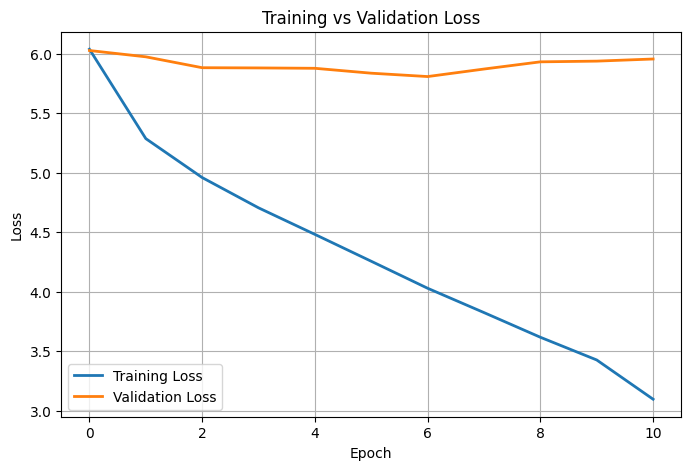

In [88]:
# ============================================================
# Training Curves
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    valid_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [89]:
# ============================================================
# Greedy Decoder
# ============================================================

def greedy_decode(
    model,
    source,
    source_length,
    target_vocab,
    max_length=50
):
    """
    Generates a translation using greedy decoding.

    Parameters
    ----------
    model : Seq2Seq
    source : Tensor
        Shape: (1, source_length)
    source_length : Tensor
        Shape: (1,)
    target_vocab : Vocabulary
    max_length : int

    Returns
    -------
    list
        List of predicted token IDs.
    """

    model.eval()

    with torch.no_grad():

        source = source.to(CFG.DEVICE)

        encoder_outputs, hidden, cell, mask = model.encode(
            source,
            source_length
        )

        input_token = torch.tensor(
            [target_vocab.sos_idx],
            device=CFG.DEVICE
        )

        generated_tokens = []

        for _ in range(max_length):

            prediction, hidden, cell, _ = model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

            best_guess = prediction.argmax(dim=1)

            token = best_guess.item()

            if token == target_vocab.eos_idx:
                break

            generated_tokens.append(token)

            input_token = best_guess

    return generated_tokens

In [90]:
# ============================================================
# Test Greedy Decoder
# ============================================================

sample_source, sample_target = dev_dataset[0]

sample_source = sample_source.unsqueeze(0).to(CFG.DEVICE)

sample_length = torch.tensor(
    [sample_source.size(1)],
    device=CFG.DEVICE
)

prediction = greedy_decode(
    model=model,
    source=sample_source,
    source_length=sample_length,
    target_vocab=target_vocab
)

print("=" * 70)

print("SOURCE:")
print(dev_df.iloc[0]["Sentence_sa"])

print("\nREFERENCE:")
print(dev_df.iloc[0]["Sentence_en"])

print("\nRAW TOKENS:")
print(prediction)

print("\nPREDICTED SENTENCE:")
print(
    target_vocab.decode(prediction)
)

SOURCE:
ते वीराः ।

REFERENCE:
those are brave men .

RAW TOKENS:
[807, 25, 89, 25, 10]

PREDICTED SENTENCE:
those two are two .


In [91]:
# ============================================================
# Translate Five Validation Samples
# ============================================================

for i in range(5):

    source, target = dev_dataset[i]

    prediction = greedy_decode(
        model,
        source.unsqueeze(0).to(CFG.DEVICE),
        torch.tensor([len(source)]).to(CFG.DEVICE),
        target_vocab
    )

    print("=" * 70)

    print("SOURCE")
    print(dev_df.iloc[i]["Sentence_sa"])

    print()

    print("REFERENCE")
    print(dev_df.iloc[i]["Sentence_en"])

    print()

    print("PREDICTION")
    print(target_vocab.decode(prediction))

    print()

SOURCE
ते वीराः ।

REFERENCE
those are brave men .

PREDICTION
those two are two .

SOURCE
' इन्फ़ैनेट् लूप् ' इतीदं व्यवस्थां निरुत्तरां कारयति ।

REFERENCE
infinite loop can cause the system to become unresponsive .

PREDICTION
this is a to the the . .

SOURCE
ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः ।

REFERENCE
" and they spit upon him , and took the reed , and smote him on the head . "

PREDICTION
" and the the , and the , and the , and the the , and the the . "

SOURCE
एते तिथी ।

REFERENCE
these two are dates .

PREDICTION
these are two . .

SOURCE
" बहुविचारेषु जातषु पितर उत्थाय कथितवान् , हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान् । "

REFERENCE
" and when there had been much disputing , peter rose up , and said unto them , men and brethren , ye know how that a good while ago god made choice among us , that the gentiles by my mouth should hear the word of the gospel , a

In [92]:
# ============================================================
# Beam Search Decoder
# ============================================================

import torch
import torch.nn.functional as F


def beam_search_decode(
    model,
    source,
    source_length,
    target_vocab,
    beam_width=3,
    max_length=50
):
    """
    Beam Search Decoder

    Parameters
    ----------
    model : Seq2Seq model

    source : Tensor
        Shape : (1, source_length)

    source_length : Tensor
        Shape : (1,)

    beam_width : int

    max_length : int

    Returns
    -------
    List[int]
        Predicted token ids
    """

    model.eval()

    with torch.no_grad():

        source = source.to(CFG.DEVICE)

        encoder_outputs, hidden, cell, mask = model.encode(
            source,
            source_length
        )

        # ----------------------------------------------------
        # Beam format:
        # (tokens, score, hidden, cell)
        # ----------------------------------------------------

        beams = [

            (
                [target_vocab.sos_idx],
                0.0,
                hidden,
                cell
            )

        ]

        completed_beams = []

        for _ in range(max_length):

            new_beams = []

            for tokens, score, h, c in beams:

                last_token = tokens[-1]

                # Stop expanding completed beams
                if last_token == target_vocab.eos_idx:

                    completed_beams.append(
                        (tokens, score)
                    )

                    continue

                input_token = torch.tensor(
                    [last_token],
                    device=CFG.DEVICE
                )

                prediction, new_hidden, new_cell, _ = model.decoder(

                    input_token,

                    h,

                    c,

                    encoder_outputs,

                    mask

                )

                log_probs = F.log_softmax(
                    prediction,
                    dim=1
                )

                top_log_probs, top_indices = torch.topk(
                    log_probs,
                    beam_width,
                    dim=1
                )

                for k in range(beam_width):

                    token = top_indices[0, k].item()

                    token_score = top_log_probs[0, k].item()

                    new_beams.append(

                        (
                            tokens + [token],

                            score + token_score,

                            new_hidden.clone(),

                            new_cell.clone()

                        )

                    )

            if len(new_beams) == 0:
                break

            new_beams = sorted(

                new_beams,

                key=lambda x: x[1],

                reverse=True

            )

            beams = new_beams[:beam_width]

        if len(completed_beams) == 0:

            completed_beams = [

                (tokens, score)

                for tokens, score, _, _ in beams

            ]

        best_tokens = max(

            completed_beams,

            key=lambda x: x[1]

        )[0]

        # Remove <SOS>

        if best_tokens[0] == target_vocab.sos_idx:

            best_tokens = best_tokens[1:]

        # Remove everything after EOS

        if target_vocab.eos_idx in best_tokens:

            eos = best_tokens.index(
                target_vocab.eos_idx
            )

            best_tokens = best_tokens[:eos]

        return best_tokens

In [93]:
# ============================================================
# Test Beam Search
# ============================================================

sample_source, sample_target = dev_dataset[0]

sample_source = sample_source.unsqueeze(0).to(CFG.DEVICE)

sample_length = torch.tensor(
    [sample_source.size(1)],
    device=CFG.DEVICE
)

prediction = beam_search_decode(

    model,

    sample_source,

    sample_length,

    target_vocab,

    beam_width=CFG.BEAM_SIZE

)

print("=" * 70)

print("SOURCE:")
print(dev_df.iloc[0]["Sentence_sa"])

print()

print("REFERENCE:")
print(dev_df.iloc[0]["Sentence_en"])

print()

print("RAW TOKENS:")
print(prediction)

print()

print("PREDICTED SENTENCE:")
print(target_vocab.decode(prediction))

SOURCE:
ते वीराः ।

REFERENCE:
those are brave men .

RAW TOKENS:
[807, 25, 89, 3960, 10]

PREDICTED SENTENCE:
those two are gopikas .


In [94]:
# ============================================================
# Generate Predictions on Development Set
# ============================================================

dev_predictions = []

print("=" * 60)
print("Generating Development Set Predictions")
print("=" * 60)

for i in tqdm(range(len(dev_dataset))):

    source, _ = dev_dataset[i]

    prediction = beam_search_decode(
        model=model,
        source=source.unsqueeze(0).to(CFG.DEVICE),
        source_length=torch.tensor(
            [len(source)],
            device=CFG.DEVICE
        ),
        target_vocab=target_vocab,
        beam_width=CFG.BEAM_SIZE
    )

    sentence = target_vocab.decode(prediction)

    dev_predictions.append(sentence)

print()

print("Total Predictions :", len(dev_predictions))

Generating Development Set Predictions


  0%|          | 0/1000 [00:00<?, ?it/s]


Total Predictions : 1000


In [95]:
# ============================================================
# Prepare Reference Sentences
# ============================================================

references = dev_df["Sentence_en"].tolist()

print("Total References :", len(references))

Total References : 1000


In [96]:
# ============================================================
# Display Sample Translations
# ============================================================

for i in range(5):

    print("=" * 70)

    print("SOURCE")
    print(dev_df.iloc[i]["Sentence_sa"])

    print()

    print("REFERENCE")
    print(references[i])

    print()

    print("PREDICTION")
    print(dev_predictions[i])

    print()

SOURCE
ते वीराः ।

REFERENCE
those are brave men .

PREDICTION
those two are gopikas .

SOURCE
' इन्फ़ैनेट् लूप् ' इतीदं व्यवस्थां निरुत्तरां कारयति ।

REFERENCE
infinite loop can cause the system to become unresponsive .

PREDICTION
this is an assignment for the .

SOURCE
ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः ।

REFERENCE
" and they spit upon him , and took the reed , and smote him on the head . "

PREDICTION
" and when he was in the , , and the the , , and they were with them . "

SOURCE
एते तिथी ।

REFERENCE
these two are dates .

PREDICTION
these two are . .

SOURCE
" बहुविचारेषु जातषु पितर उत्थाय कथितवान् , हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान् । "

REFERENCE
" and when there had been much disputing , peter rose up , and said unto them , men and brethren , ye know how that a good while ago god made choice among us , that the gentiles by my mouth should hear the word

In [97]:
# ============================================================
# BLEU Score Evaluation
# ============================================================

from nltk.translate.bleu_score import corpus_bleu

# ------------------------------------------------------------
# Prepare References and Predictions
# ------------------------------------------------------------

bleu_references = [

    [reference.split()]

    for reference in references

]

bleu_predictions = [

    prediction.split()

    for prediction in dev_predictions

]

# ------------------------------------------------------------
# Compute BLEU Score
# ------------------------------------------------------------

bleu_score = corpus_bleu(

    bleu_references,

    bleu_predictions

)

print("=" * 60)
print("BLEU Score Evaluation")
print("=" * 60)

print(f"Corpus BLEU Score : {bleu_score:.4f}")

print(f"Corpus BLEU (%)   : {bleu_score * 100:.2f}%")

BLEU Score Evaluation
Corpus BLEU Score : 0.0523
Corpus BLEU (%)   : 5.23%


In [98]:
# ============================================================
# BERTScore Evaluation
# ============================================================

from bert_score import score as bert_score

print("=" * 60)
print("Computing BERTScore...")
print("=" * 60)

P, R, F1 = bert_score(
    cands=dev_predictions,
    refs=references,
    lang="en",
    rescale_with_baseline=True
)

average_precision = P.mean().item()
average_recall = R.mean().item()
average_f1 = F1.mean().item()

print()
print("=" * 60)
print("BERTScore Evaluation")
print("=" * 60)

print(f"Precision : {average_precision:.4f}")
print(f"Recall    : {average_recall:.4f}")
print(f"F1 Score  : {average_f1:.4f}")

print()
print(f"BERTScore (F1 %) : {average_f1 * 100:.2f}%")

Computing BERTScore...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERTScore Evaluation
Precision : 0.1393
Recall    : 0.0872
F1 Score  : 0.1132

BERTScore (F1 %) : 11.32%


In [99]:
# ============================================================
# Measure Inference Time
# ============================================================

import time

print("=" * 60)
print("Measuring Inference Time")
print("=" * 60)

start_time = time.time()

test_predictions = []

for i in tqdm(range(len(test_df))):

    source_sentence = test_df.iloc[i]["Sentence_sa"]

    source_ids = source_vocab.numericalize(source_sentence)

    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long
    ).unsqueeze(0).to(CFG.DEVICE)

    source_length = torch.tensor(
        [len(source_ids)],
        device=CFG.DEVICE
    )

    prediction = beam_search_decode(
        model=model,
        source=source_tensor,
        source_length=source_length,
        target_vocab=target_vocab,
        beam_width=CFG.BEAM_SIZE
    )

    test_predictions.append(
        target_vocab.decode(prediction)
    )

end_time = time.time()

inference_time = end_time - start_time

print()
print("=" * 60)
print("Inference Completed")
print("=" * 60)

print(f"Total Test Samples : {len(test_predictions)}")
print(f"Inference Time     : {inference_time:.2f} seconds")
print(f"Average Time/Sample: {inference_time/len(test_predictions):.4f} seconds")

Measuring Inference Time


  0%|          | 0/1000 [00:00<?, ?it/s]


Inference Completed
Total Test Samples : 1000
Inference Time     : 177.12 seconds
Average Time/Sample: 0.1771 seconds


In [100]:
# ============================================================
# Model Efficiency
# ============================================================

print("=" * 60)
print("Model Efficiency")
print("=" * 60)

print(f"Trainable Parameters : {trainable_parameters:,}")
print(f"Total Parameters     : {total_parameters:,}")

print(f"\nInference Time       : {inference_time:.2f} seconds")
print(f"Time Per Sentence    : {inference_time/len(test_predictions):.4f} seconds")

Model Efficiency
Trainable Parameters : 20,259,200
Total Parameters     : 20,259,200

Inference Time       : 177.12 seconds
Time Per Sentence    : 0.1771 seconds


In [101]:
# ============================================================
# Generate Submission File
# ============================================================

submission = pd.DataFrame({

    "Source_id": test_df["Source_id"],

    "Sentence_en": test_predictions

})

submission.to_csv(

    "submission.csv",

    index=False,

    encoding="utf-8"

)

print("=" * 60)
print("Submission File Created Successfully")
print("=" * 60)

display(submission.head())

print("\nSaved as : submission.csv")

Submission File Created Successfully


,Source_id,Sentence_en
0,1,this is a file in the .
1,2,""" but i have to the , , and the , , and the , ..."
2,3,"so , click on the image and click on the image..."
3,4,"in the number of the , , , , , , , , the numbe..."
4,5,""" and when he was in the , , and the the , , a..."



Saved as : submission.csv


In [102]:
# ============================================================
# Save Training History
# ============================================================

history = pd.DataFrame({

    "Epoch": range(1, len(train_losses) + 1),

    "Train Loss": train_losses,

    "Validation Loss": valid_losses

})

history.to_csv(

    "training_history.csv",

    index=False

)

print(history.head())

   Epoch  Train Loss  Validation Loss
0      1    6.038407         6.027599
1      2    5.286963         5.974544
2      3    4.959660         5.882999
3      4    4.705207         5.881197
4      5    4.481977         5.878101


In [103]:
# ============================================================
# Final Evaluation Summary
# ============================================================

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print(f"BLEU Score           : {bleu_score:.4f}")
print(f"BLEU (%)             : {bleu_score * 100:.2f}%")

print()

print(f"BERTScore (F1)       : {average_f1:.4f}")
print(f"BERTScore (F1 %)     : {average_f1 * 100:.2f}%")

print()

print(f"Trainable Parameters : {trainable_parameters:,}")

print(f"Inference Time       : {inference_time:.2f} seconds")

print(f"Time / Sentence      : {inference_time/len(test_predictions):.4f} seconds")

print("=" * 70)

FINAL MODEL EVALUATION
BLEU Score           : 0.0523
BLEU (%)             : 5.23%

BERTScore (F1)       : 0.1132
BERTScore (F1 %)     : 11.32%

Trainable Parameters : 20,259,200
Inference Time       : 177.12 seconds
Time / Sentence      : 0.1771 seconds


In [104]:
# ============================================================
# Translation Examples
# ============================================================

for i in range(10):

    print("=" * 80)

    print("SOURCE")
    print(dev_df.iloc[i]["Sentence_sa"])

    print("\nREFERENCE")
    print(references[i])

    print("\nPREDICTION")
    print(dev_predictions[i])

    print()

SOURCE
ते वीराः ।

REFERENCE
those are brave men .

PREDICTION
those two are gopikas .

SOURCE
' इन्फ़ैनेट् लूप् ' इतीदं व्यवस्थां निरुत्तरां कारयति ।

REFERENCE
infinite loop can cause the system to become unresponsive .

PREDICTION
this is an assignment for the .

SOURCE
ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः ।

REFERENCE
" and they spit upon him , and took the reed , and smote him on the head . "

PREDICTION
" and when he was in the , , and the the , , and they were with them . "

SOURCE
एते तिथी ।

REFERENCE
these two are dates .

PREDICTION
these two are . .

SOURCE
" बहुविचारेषु जातषु पितर उत्थाय कथितवान् , हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान् । "

REFERENCE
" and when there had been much disputing , peter rose up , and said unto them , men and brethren , ye know how that a good while ago god made choice among us , that the gentiles by my mouth should hear the word